In [8]:
%matplotlib notebook
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [9]:
data=pd.read_csv('./data/Restaurant/df_final_dataset2.csv')

## Covariance of Two Variables

In [10]:
data.cov()

,customer_id,item_count,grand_total,vendor_rating_x,vendor_id,rank
customer_id,1.839629e+06,-148.449541,-2107.355958,-119.374516,24058.167702,-385.616743
item_count,-1.484495e+02,2.581171,12.450691,-0.012149,-13.249272,0.128139
grand_total,-2.107356e+03,12.450691,164.684165,0.321234,-237.835307,-0.038334
vendor_rating_x,-1.193745e+02,-0.012149,0.321234,1.073900,-21.528422,0.038530
vendor_id,2.405817e+04,-13.249272,-237.835307,-21.528422,56809.334195,-194.113627
rank,-3.856167e+02,0.128139,-0.038334,0.038530,-194.113627,9.354432


## Correlation of Two Variables

<IPython.core.display.Javascript object>


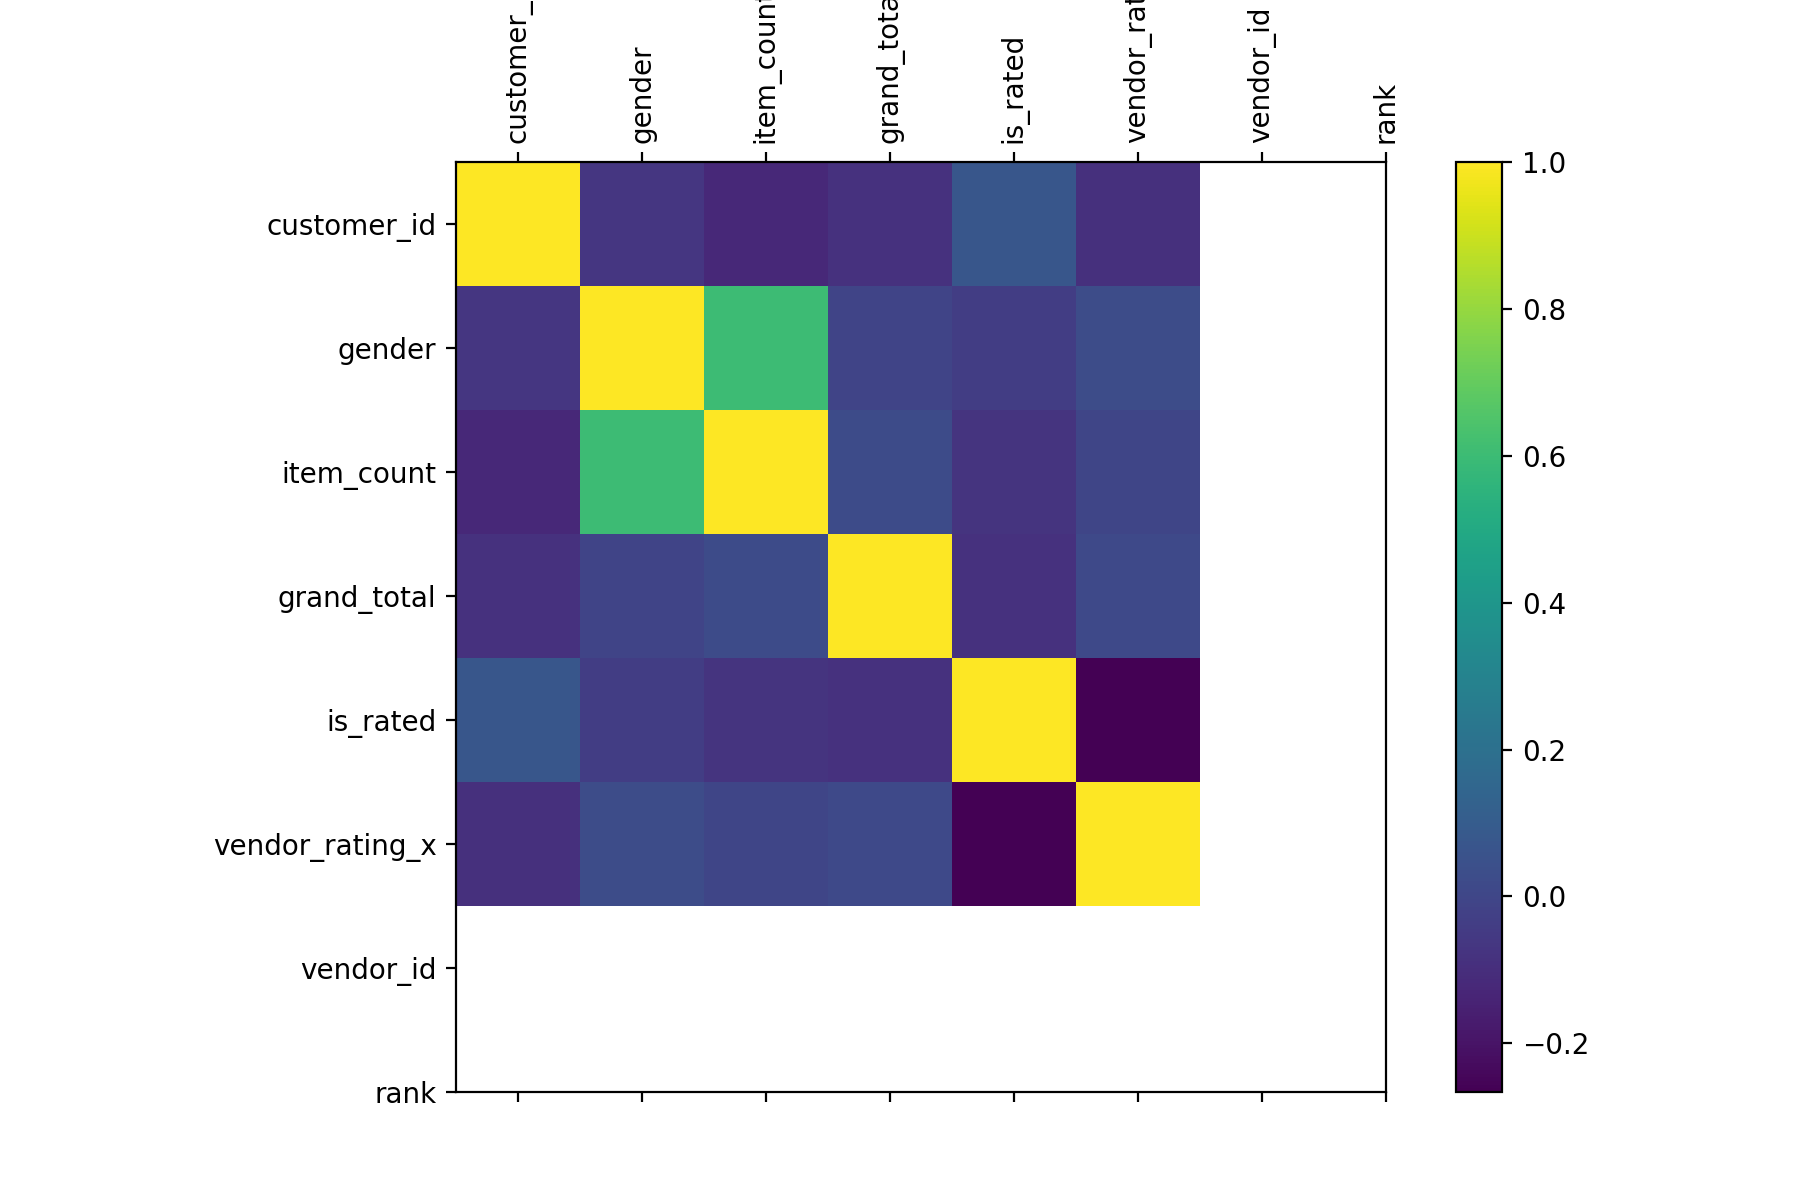

In [13]:
f = plt.figure(figsize=(9, 6))
plt.matshow(data.corr(), fignum=f.number)
plt.xticks (range (len (data.columns)), data.columns, rotation='vertical') 
plt.yticks(range (len (data.columns)), data.columns) 
plt.colorbar()
plt.show ()

In [12]:
data.corr(method='pearson')

,customer_id,item_count,grand_total,vendor_rating_x,vendor_id,rank
customer_id,1.000000,-0.068125,-0.121073,-0.084931,0.074420,-0.092957
item_count,-0.068125,1.000000,0.603892,-0.007297,-0.034600,0.026077
grand_total,-0.121073,0.603892,1.000000,0.024155,-0.077757,-0.000977
vendor_rating_x,-0.084931,-0.007297,0.024155,1.000000,-0.087161,0.012156
vendor_id,0.074420,-0.034600,-0.077757,-0.087161,1.000000,-0.266279
rank,-0.092957,0.026077,-0.000977,0.012156,-0.266279,1.000000


## Linear Regression

In [8]:
from sklearn import linear_model

linreg = linear_model.LinearRegression()
linreg.fit(data.grand_total.to_numpy().reshape(-1,1), data.vendor_rating_x)

LinearRegression()

In [9]:
print('The coefficient is ', linreg.coef_)

predicted_rating = linreg.predict(data.grand_total.to_numpy().reshape(-1,1))

The coefficient is  [0.00195061]


In [10]:
#calculate the sum square error (SSE)
sse = np.sum(np.square(predicted_rating - data.vendor_rating_x))

#calculate the mean square error (MSE)
mse = np.mean(np.square(predicted_rating - data.vendor_rating_x))

#calculate the root mean square error (RMS)
rms = np.sqrt(mse)

print('SSE=', sse, 'MSE=', mse, 'RMS=', rms)

SSE= 40812.28270460435 MSE= 1.073244870870766 RMS= 1.0359753234854419


In [11]:
linreg.score(data.grand_total.to_numpy().reshape(-1,1), data.vendor_rating_x)

0.000583481438652278

<IPython.core.display.Javascript object>


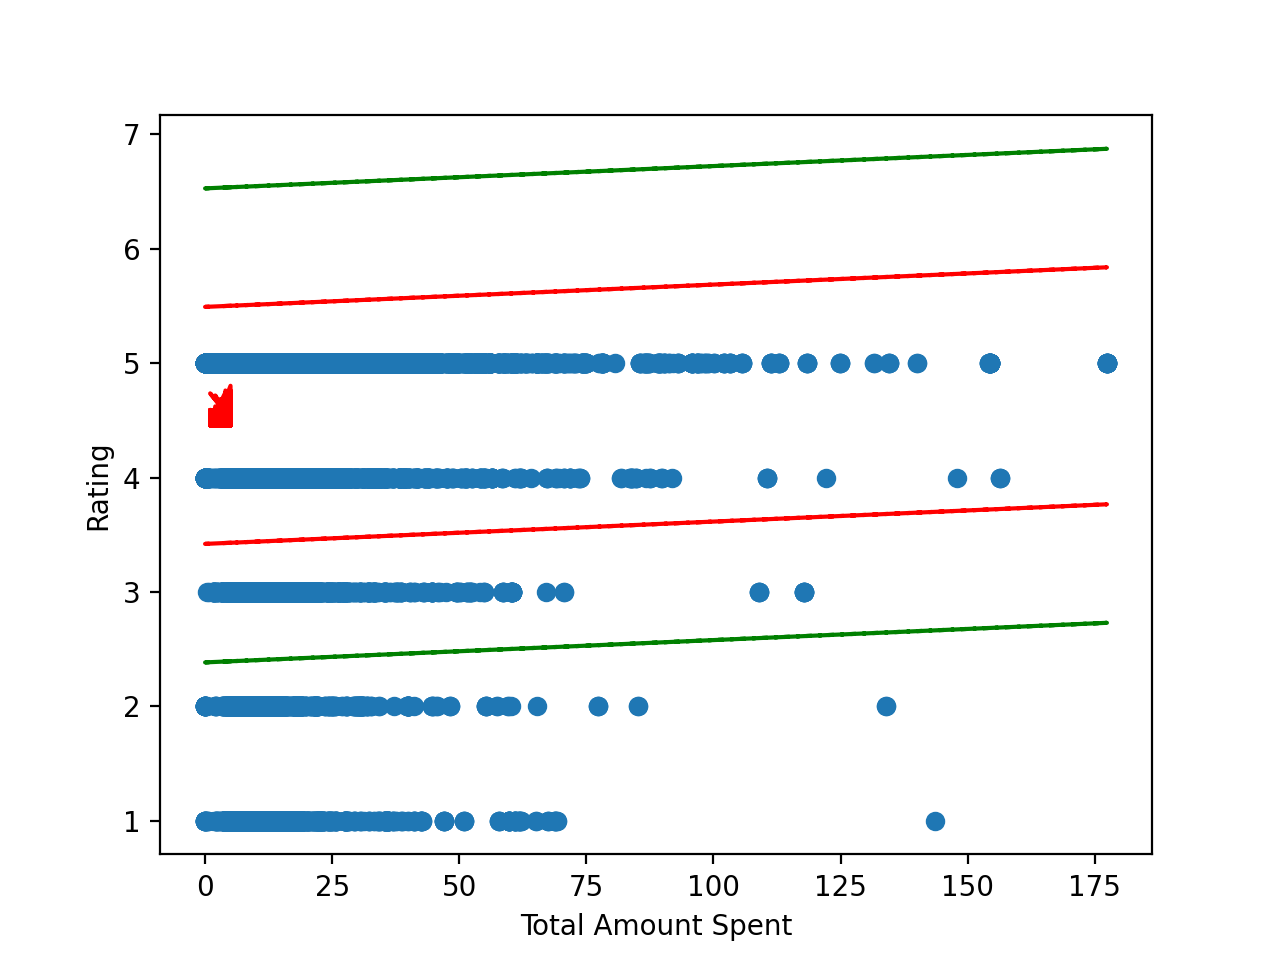

In [13]:
#Visualise the linear regression model
fig = plt.figure()

axis = fig.add_subplot(111)

axis.scatter(data.grand_total, data.vendor_rating_x)
axis.plot(data.vendor_rating_x, predicted_rating, color='r')

#Visualise the bounds of one RMS
axis.plot(data.grand_total, predicted_rating+rms, '--', color='r')
axis.plot(data.grand_total, predicted_rating-rms, '--', color='r')

#Visualise the bounds of two RMS
axis.plot(data.grand_total, predicted_rating+rms*2.0, '--', color='g')
axis.plot(data.grand_total, predicted_rating-rms*2.0, '--', color='g')
axis.set_xlabel('Total Amount Spent')
axis.set_ylabel('Rating')
plt.show()